# Pha T - Nhịp 3: Hiệu chỉnh Bias (Bias Calibration) cho Amortized


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from pqrst.estimators.calibration import calibrate_grid_leave_one_config_out

BASE = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
tables_dir = BASE / 'results' / 'tables'
fig_dir = BASE / 'results' / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)


In [6]:
def process_dataset(csv_name, dataset_type):
    df = pd.read_csv(tables_dir / csv_name)
    df_cal_amo = calibrate_grid_leave_one_config_out(df, 'Amortized')
    df_cal_ksg = calibrate_grid_leave_one_config_out(df, 'KSG')
    
    df_orig = df[df['estimator'].isin(['KSG', 'Amortized'])].copy()
    
    df_comb = pd.concat([df_orig, df_cal_amo, df_cal_ksg], ignore_index=True)
    df_comb['dataset'] = dataset_type
    return df_comb

df_lin = process_dataset('phase_r_grid_summary.csv', 'Linear VAR')
df_per = process_dataset('phase_r2_periodic_grid_summary.csv', 'Periodic Coupling')

df_final = pd.concat([df_lin, df_per], ignore_index=True)
df_final.to_csv(tables_dir / 'phase_t_bias_calibration_summary.csv', index=False)
print("Saved phase_t_bias_calibration_summary.csv")


Saved phase_t_bias_calibration_summary.csv


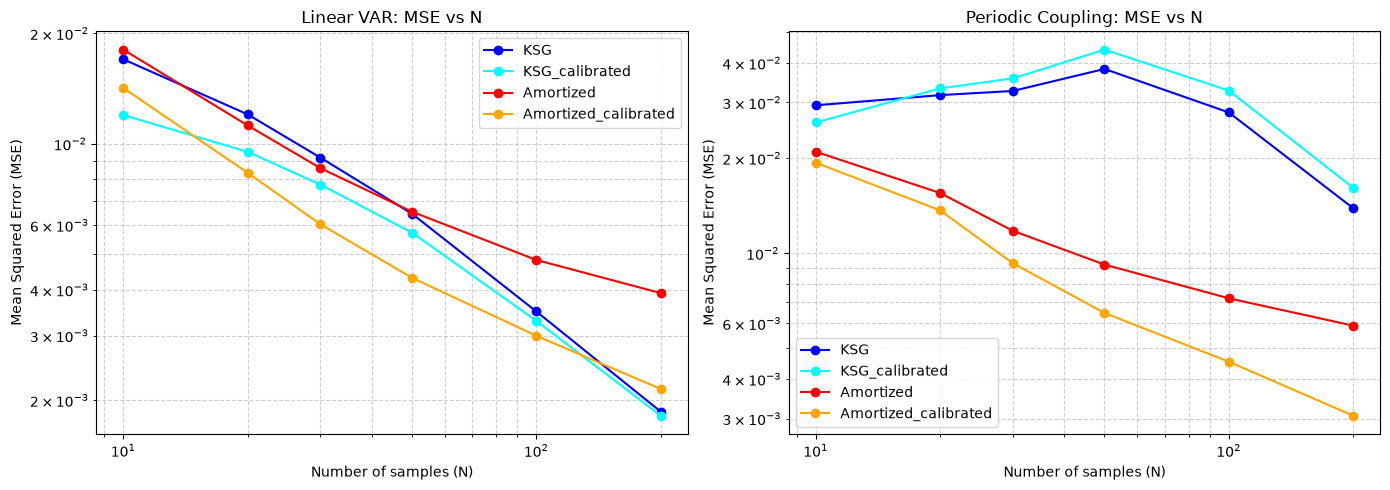

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
estimators = ['KSG', 'KSG_calibrated', 'Amortized', 'Amortized_calibrated']
colors = {'KSG': 'blue', 'KSG_calibrated': 'cyan', 'Amortized': 'red', 'Amortized_calibrated': 'orange'}

def plot_mse(ax, df_subset, title):
    df_agg = df_subset.groupby(['n_samples', 'estimator'])['mse'].mean().unstack()
    for est in estimators:
        if est in df_agg:
            ax.plot(df_agg.index, df_agg[est], marker='o', label=est, color=colors.get(est, 'gray'))
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Number of samples (N)')
    ax.set_ylabel('Mean Squared Error (MSE)')
    ax.set_title(title)
    ax.grid(True, which='both', linestyle='--', alpha=0.6)
    ax.legend()
    return df_agg

agg_lin = plot_mse(axes[0], df_lin, 'Linear VAR: MSE vs N')
agg_per = plot_mse(axes[1], df_per, 'Periodic Coupling: MSE vs N')

plt.tight_layout()
plt.savefig(fig_dir / 'phase_t_bias_calibration_mse.png', dpi=100)
plt.show()


In [8]:
print("KET LUAN VE HIEU QUAN CUA CALIBRATION (MSE):")
print("-" * 50)
def analyze_domain(name, agg):
    print(f"\nDataset: {name}")
    for n in agg.index:
        ksg = agg.loc[n, 'KSG']
        ksg_cal = agg.loc[n, 'KSG_calibrated']
        amo = agg.loc[n, 'Amortized']
        amo_cal = agg.loc[n, 'Amortized_calibrated']
        
        ksg_improved = "YES" if (ksg - ksg_cal) > 0 else "NO"
        amo_wins = amo_cal < ksg_cal
        winner = "Amortized_calibrated" if amo_wins else "KSG_calibrated"
        
        print(f"  - N={n}: KSG improved? {ksg_improved} ({ksg:.5f} -> {ksg_cal:.5f}). "
              f"Winner: {winner} ({min(amo_cal, ksg_cal):.5f} vs {max(amo_cal, ksg_cal):.5f})")

analyze_domain("Linear VAR", agg_lin)
analyze_domain("Periodic Coupling", agg_per)


KET LUAN VE HIEU QUAN CUA CALIBRATION (MSE):
--------------------------------------------------

Dataset: Linear VAR
  - N=10: KSG improved? YES (0.01700 -> 0.01197). Winner: KSG_calibrated (0.01197 vs 0.01419)
  - N=20: KSG improved? YES (0.01203 -> 0.00951). Winner: Amortized_calibrated (0.00833 vs 0.00951)
  - N=30: KSG improved? YES (0.00917 -> 0.00773). Winner: Amortized_calibrated (0.00604 vs 0.00773)
  - N=50: KSG improved? YES (0.00645 -> 0.00572). Winner: Amortized_calibrated (0.00431 vs 0.00572)
  - N=100: KSG improved? YES (0.00349 -> 0.00329). Winner: Amortized_calibrated (0.00300 vs 0.00329)
  - N=200: KSG improved? YES (0.00186 -> 0.00181). Winner: KSG_calibrated (0.00181 vs 0.00215)

Dataset: Periodic Coupling
  - N=10: KSG improved? YES (0.02938 -> 0.02593). Winner: Amortized_calibrated (0.01934 vs 0.02593)
  - N=20: KSG improved? NO (0.03165 -> 0.03325). Winner: Amortized_calibrated (0.01367 vs 0.03325)
  - N=30: KSG improved? NO (0.03262 -> 0.03575). Winner: Amortized